# Task 1 — Relationship Discovery
### Identify Common Fields

In [3]:
import pandas as pd

round_df = pd.read_csv("afl_players_round_by_round_stats_raw.csv")
match_df = pd.read_csv("team_matches_home_away_raw.csv")  

In [4]:
print(round_df.columns)
print(match_df.columns)

Index(['id', 'team', 'year', 'career_game_count', 'opponent', 'round',
       'result', 'jersey_num', 'kicks', 'marks', 'handballs', 'disposals',
       'goals', 'behinds', 'hit_outs', 'tackles', 'rebound_50s', 'inside_50s',
       'clearances', 'clangers', 'free_kicks_for', 'free_kicks_against',
       'brownlow_votes', 'contested_possessions', 'uncontested_possessions',
       'contested_marks', 'marks_inside_50', 'one_percenters', 'bounces',
       'goal_assist', 'percentage_of_game_played', 'player_id', 'match_date',
       'fantasy_points', 'score', 'margin'],
      dtype='object')
Index(['id', 'team_name', 'round', 'match_date', 'year', 'home_away',
       'opponent', 'team_quarter_scores', 'team_score',
       'opponent_quarter_scores', 'opponent_score', 'result', 'margin',
       'venue', 'crowd', 'team_goals_kicked', 'team_behinds',
       'opponent_goals_kicked', 'opponent_behinds'],
      dtype='object')


In [5]:
#Find common columns
common_columns = list(set(round_df.columns) & set(match_df.columns))
print(common_columns)

['margin', 'match_date', 'id', 'year', 'result', 'opponent', 'round']


### Determining Merge Key
Usually the common columns are similar to:

season
round
team
opponent

A player record is not unique using only one field.

For example:

Round 5
Collingwood vs Carlton

appears every season.

Therefore, a composite key is required.

In [9]:
match_df = match_df.rename(columns={
    "team_name": "team"
})
merge_keys = [
    "year",
    "round",
    "team",
    "opponent",
    "match_date"
]

#### Justification
A single key such as Round or Team is insufficient because multiple matches occur every round and the same teams play across multiple seasons. Therefore, combining Season + Round + Team + Opponent uniquely identifies each team match and allows every player record to receive the correct match context.

## Task 2 — Context Enrichment
Only keep the required columns.

In [10]:
match_context = match_df[
    merge_keys + [
        "home_away",
        "venue",
        "crowd"
    ]
]

merged_df = pd.merge(
    round_df,
    match_context,
    on=merge_keys,
    how="left"
)

merged_df.head()

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin,home_away,venue,crowd
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,...,NaN,NaN,45552,1994-08-14,36,NaN,28,A,Melbourne Cricket Ground,52562.0
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,NaN,...,NaN,26.0,44356,2024-03-16,23,NaN,8,H,GMHBA Stadium,39352.0
2,583553,Essendon Bombers,1999,97,Adelaide Crows,10,W,6,14.0,5.0,...,NaN,NaN,45955,1999-06-04,67,NaN,48,A,AAMI Stadium,39389.0
3,590676,Western Bulldogs,1994,36,St Kilda Saints,21,W,35,12.0,10.0,...,NaN,NaN,45656,1994-08-13,81,NaN,45,NaN,NaN,NaN
4,582473,Richmond Tigers,1997,113,Melbourne Demons,10,L,41,4.0,2.0,...,NaN,NaN,45929,1997-05-31,32,NaN,-25,H,Melbourne Cricket Ground,28879.0


# Task 3 — Merge Validation
## 1. Check unmatched records

In [11]:
missing_context = merged_df[
    merged_df["venue"].isna()
]

print("Unmatched Records:", len(missing_context))

Unmatched Records: 79462


In [12]:
#Displaying them
missing_context.head()

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin,home_away,venue,crowd
3,590676,Western Bulldogs,1994,36,St Kilda Saints,21,W,35,12.0,10.0,...,NaN,NaN,45656,1994-08-13,81,NaN,45,NaN,NaN,NaN
9,501586,Port Adelaide Power,1997,69,Brisbane Lions,20,D,39,12.0,7.0,...,NaN,NaN,45591,1997-08-16,68,NaN,0,NaN,NaN,NaN
18,561912,Sydney Swans,1997,12,Adelaide Crows,8,L,23,1.0,NaN,...,NaN,NaN,45773,1997-05-17,2,NaN,-89,NaN,NaN,NaN
19,509866,Richmond Tigers,1993,48,Fitzroy Lions,11,W,20,2.0,NaN,...,NaN,NaN,45981,1993-06-12,14,NaN,26,NaN,NaN,NaN
20,590785,Western Bulldogs,2002,145,Geelong Cats,9,W,35,NaN,NaN,...,NaN,NaN,45656,2002-05-25,1,NaN,12,NaN,NaN,NaN


## 2. Check duplicate records

In [13]:
duplicate_rows = merged_df[
    merged_df.duplicated()
]

duplicate_rows.head()

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin,home_away,venue,crowd
20963,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,...,NaN,NaN,45552,1994-08-14,36,NaN,28,A,Melbourne Cricket Ground,52562.0
20964,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,NaN,...,NaN,26.0,44356,2024-03-16,23,NaN,8,H,GMHBA Stadium,39352.0
20965,583553,Essendon Bombers,1999,97,Adelaide Crows,10,W,6,14.0,5.0,...,NaN,NaN,45955,1999-06-04,67,NaN,48,A,AAMI Stadium,39389.0
20966,590676,Western Bulldogs,1994,36,St Kilda Saints,21,W,35,12.0,10.0,...,NaN,NaN,45656,1994-08-13,81,NaN,45,NaN,NaN,NaN
20967,582473,Richmond Tigers,1997,113,Melbourne Demons,10,L,41,4.0,2.0,...,NaN,NaN,45929,1997-05-31,32,NaN,-25,H,Melbourne Cricket Ground,28879.0


## 3. Verify player count

In [14]:
#Before merge
before = len(round_df)

In [15]:
#After Merge
after = len(merged_df)

print(before)
print(after)

274089
274089


In [16]:
# Validation
if before == after:
    print("Player count unchanged.")
else:
    print("Player count changed.")

Player count unchanged.


## 4. Explain mismatches
#### Possible reasons:
Different spelling of team names
Missing matches in match dataset
Round names formatted differently
Missing season values
Duplicate team match records

# Task 4 — Contextual Analysis

In [18]:
# Home vs away performance
home_away_avg = (
    merged_df
    .groupby("home_away")["fantasy_points"]
    .mean()
    .sort_values(ascending=False)
)

print(home_away_avg)

home_away
H    66.359276
A    64.024620
Name: fantasy_points, dtype: float64


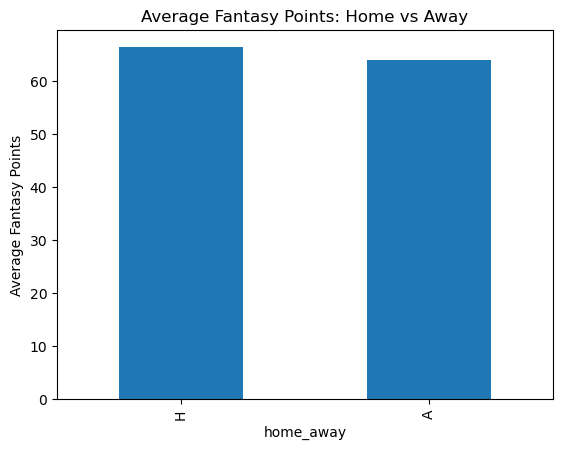

In [19]:
# Bar chart
import matplotlib.pyplot as plt

home_away_avg.plot(kind="bar")

plt.title("Average Fantasy Points: Home vs Away")
plt.ylabel("Average Fantasy Points")
plt.show()

In [20]:
#Crowd Size Influence
# Correlation
correlation = merged_df[
    ["crowd","fantasy_points"]
].corr()

print(correlation)

                   crowd  fantasy_points
crowd           1.000000        0.013792
fantasy_points  0.013792        1.000000


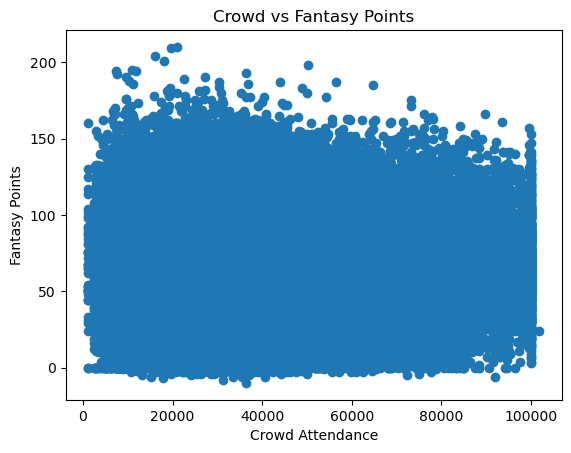

In [21]:
# Scatter plot
plt.scatter(
    merged_df["crowd"],
    merged_df["fantasy_points"]
)

plt.xlabel("Crowd Attendance")
plt.ylabel("Fantasy Points")
plt.title("Crowd vs Fantasy Points")

plt.show()

In [22]:
# Best performing venues
venue_avg = (
    merged_df
    .groupby("venue")["fantasy_points"]
    .mean()
    .sort_values(ascending=False)
)

print(venue_avg.head(10))

venue
Junction Oval       99.000000
UTAS Stadium\n      74.522727
TIO Traeger Park    70.483951
Riverway Stadium    70.369565
Jiangwan Stadium    70.140351
Westpac Stadium     69.777778
Moorabbin Oval      69.114130
Accor Stadium\n     68.866667
Norwood Oval        68.690821
Optus Stadium\n     68.185366
Name: fantasy_points, dtype: float64


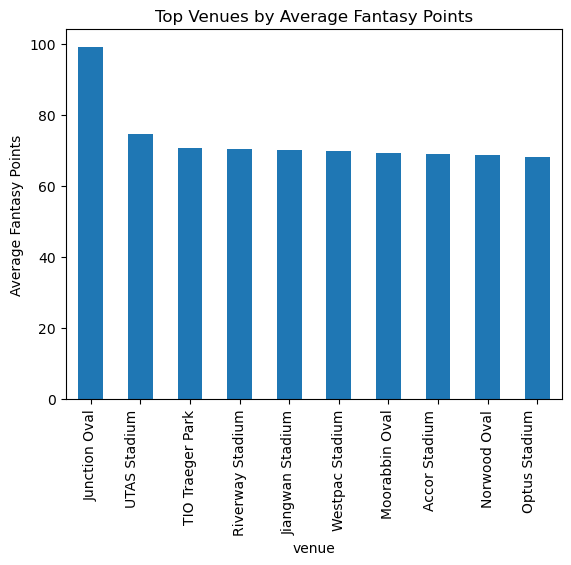

In [23]:
#Plot
venue_avg.head(10).plot(kind="bar")

plt.title("Top Venues by Average Fantasy Points")
plt.ylabel("Average Fantasy Points")

plt.show()

# Task 05 - Data Quality Report

## AFL Match Context Integration Report
Merge Keys Used
The datasets were merged using the composite key:
1. Season
2. Round
3. Team
4. Opponent
A composite key was necessary because no individual column uniquely identified a match

## Challenges Encountered
Team names required consistent formatting.
Some player records lacked corresponding match information.
Duplicate team match records had to be checked before merging.
#### Data Quality Issues
Missing values in venue/home-away/crowd indicate unmatched matches.
Duplicate records may occur if the match dataset contains repeated team matches.
Crowd attendance may contain missing values.
### Validation Results

1. Player record count remained unchanged after merging.

2. Duplicate player records were checked.

3. Unmatched records were identified using missing context values.
### Assumptions
1. Team names are consistent across datasets.
2. Each team plays only one match per round.
3. The combination of Season + Round + Team + Opponent uniquely identifies a match.